# StaySure Hotel Cancellation ML
## Milestone 4 — Baseline Modeling and Evaluation

**Business goal:** establish honest baseline performance for predicting hotel cancellations before testing more complex models.

This learner-led notebook compares a no-skill `DummyClassifier` with an interpretable logistic-regression baseline. Models learn from the chronological training period and are compared on the later validation period. The test set remains sealed for later final evaluation.

### Main outputs

- `models/logistic_regression_baseline.joblib` — local fitted baseline model (ignored by Git)
- `reports/milestone_04_baseline_metrics.csv` — validation metrics by model
- `reports/milestone_04_confusion_matrix.csv` — logistic-regression error counts
- `reports/milestone_04_threshold_analysis.csv` — precision/recall trade-offs


### What you should be able to explain afterward

1. Why every useful model must beat a no-skill baseline.
2. Why accuracy alone can be misleading.
3. The meaning of precision, recall, F1 score, and ROC AUC.
4. What false positives and false negatives mean for a hotel.
5. Why model selection uses validation data while test data remains untouched.
6. How the probability threshold changes business trade-offs.


## 1. Setup


In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
RANDOM_STATE = 42
print("Libraries loaded.")


Libraries loaded.


In [2]:
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
CLEAN_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "hotel_bookings_clean.csv"
PREPROCESSOR_PATH = PROJECT_ROOT / "models" / "preprocessing_pipeline.joblib"
FEATURE_MANIFEST_PATH = PROJECT_ROOT / "reports" / "milestone_03_feature_manifest.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)


Project root: C:\Users\theko\ML_Projects\staysure-hotel-cancellation-ml


## 2. Recreate the Milestone 3 chronological split


In [3]:
for required_path in [CLEAN_DATA_PATH, PREPROCESSOR_PATH, FEATURE_MANIFEST_PATH]:
    if not required_path.exists():
        raise FileNotFoundError(f"Required Milestone 3 artifact not found: {required_path}")

df = pd.read_csv(CLEAN_DATA_PATH)
manifest = pd.read_csv(FEATURE_MANIFEST_PATH)
FEATURE_COLUMNS = manifest["source_feature"].tolist()
TARGET = "is_canceled"

month_number = {month: number for number, month in enumerate([
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
], start=1)}
df["arrival_date"] = pd.to_datetime({
    "year": df["arrival_date_year"],
    "month": df["arrival_date_month"].map(month_number),
    "day": df["arrival_date_day_of_month"],
})
df = df.sort_values("arrival_date").reset_index(drop=True)

train_df = df[df["arrival_date"] <= "2017-02-10"].copy()
valid_df = df[(df["arrival_date"] > "2017-02-10") & (df["arrival_date"] <= "2017-05-21")].copy()
test_df = df[df["arrival_date"] > "2017-05-21"].copy()

X_train, y_train = train_df[FEATURE_COLUMNS].copy(), train_df[TARGET].copy()
X_valid, y_valid = valid_df[FEATURE_COLUMNS].copy(), valid_df[TARGET].copy()
X_test, y_test = test_df[FEATURE_COLUMNS].copy(), test_df[TARGET].copy()

print("Train:", X_train.shape, f"cancellation rate={y_train.mean():.2%}")
print("Validation:", X_valid.shape, f"cancellation rate={y_valid.mean():.2%}")
print("Test (sealed):", X_test.shape)


Train: (82937, 27) cancellation rate=36.30%
Validation: (17758, 27) cancellation rate=39.47%
Test (sealed): (17869, 27)


## 3. Apply the fitted preprocessing pipeline


In [4]:
preprocessor = joblib.load(PREPROCESSOR_PATH)
X_train_ready = preprocessor.transform(X_train)
X_valid_ready = preprocessor.transform(X_valid)

assert X_train_ready.shape[1] == X_valid_ready.shape[1]
assert X_train_ready.shape[0] == len(y_train)
assert X_valid_ready.shape[0] == len(y_valid)
print("Train matrix:", X_train_ready.shape)
print("Validation matrix:", X_valid_ready.shape)
print("Test data was not transformed or evaluated.")


Train matrix: (82937, 522)
Validation matrix: (17758, 522)
Test data was not transformed or evaluated.


## 4. Define an evaluation function

Accuracy measures all correct predictions, but it does not describe which class is being predicted well. We will also calculate:

- **Precision:** among predicted cancellations, how many actually canceled?
- **Recall:** among actual cancellations, how many did the model find?
- **F1:** harmonic balance of precision and recall.
- **ROC AUC:** how well predicted probabilities rank cancellations above non-cancellations across thresholds.


### TODO 1 — Complete the metric calculations


In [5]:
def evaluate_classifier(model_name, y_true, y_pred, y_probability):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        # TODO 1: Replace each None with the matching metric function call.
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_probability),
    }

print("Evaluation function defined. Complete TODO 1 before evaluating models.")


Evaluation function defined. Complete TODO 1 before evaluating models.


## 5. Build the no-skill baseline

The dummy model provides the minimum benchmark. With `most_frequent`, it always predicts the majority class observed during training.


### TODO 2 — Configure and fit the dummy classifier


In [6]:
# TODO 2: Replace None with the strategy described above.
DUMMY_STRATEGY = "most_frequent"

if DUMMY_STRATEGY is None:
    print("TODO 2: Set DUMMY_STRATEGY before continuing.")
    dummy_model = None
else:
    dummy_model = DummyClassifier(strategy=DUMMY_STRATEGY, random_state=RANDOM_STATE)
    dummy_model.fit(X_train_ready, y_train)
    dummy_predictions = dummy_model.predict(X_valid_ready)
    dummy_probabilities = dummy_model.predict_proba(X_valid_ready)[:, 1]
    dummy_metrics = evaluate_classifier(
        "Dummy (most frequent)", y_valid, dummy_predictions, dummy_probabilities
    )
    display(pd.DataFrame([dummy_metrics]))


,model,accuracy,precision,recall,f1,roc_auc
0,Dummy (most frequent),0.6053,0.0000,0.0000,0.0000,0.5000


**TODO 2 explanation:** Why can a model achieve roughly 60% accuracy here while having zero recall for cancellations?

## DUMMY_STRATEGY Descision
The dummy model achieves roughly 60% accuracy because about 60% of the validation reservations did not cancel. It predicts the majority class, “not canceled” for every reservation. Therefore, it correctly classifies most non-cancellations but identifies none of the actual cancellations, resulting in zero recall, precision, and F1 score for the cancellation class.


## 6. Train an interpretable logistic-regression baseline


### TODO 3 — Configure logistic regression


In [7]:
# TODO 3: Replace None with values that allow convergence and reproducibility.
MAX_ITERATIONS = 2000
SOLVER = "liblinear"

if MAX_ITERATIONS is None or SOLVER is None:
    print("TODO 3: Set MAX_ITERATIONS and SOLVER before continuing.")
    logistic_model = None
else:
    logistic_model = LogisticRegression(
        max_iter=MAX_ITERATIONS,
        solver=SOLVER,
        random_state=RANDOM_STATE,
    )
    logistic_model.fit(X_train_ready, y_train)
    logistic_predictions = logistic_model.predict(X_valid_ready)
    logistic_probabilities = logistic_model.predict_proba(X_valid_ready)[:, 1]
    logistic_metrics = evaluate_classifier(
        "Logistic regression", y_valid, logistic_predictions, logistic_probabilities
    )
    display(pd.DataFrame([logistic_metrics]))


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic regression,0.7960,0.7632,0.7004,0.7305,0.8753


Recommended values for this dataset are `2000` iterations and the `"liblinear"` solver. Explain why logistic regression is a useful baseline even if a later nonlinear model performs better.

## LOGISTIC REGRESSION as BASELINE Decision
Logistic regression is a useful baseline because it is relatively fast, interpretable, and produces cancellation probabilities. It establishes whether a straightforward linear model can meaningfully outperform the no-skill benchmark before more complex models are introduced. Its coefficients can also help explain how features influence cancellation predictions.


## 7. Compare validation performance


### TODO 4 — Build and rank the comparison table


In [8]:
if dummy_model is None or logistic_model is None:
    print("Complete TODOs 1–3 first.")
else:
    # TODO 4: Put the two metric dictionaries inside the list.
    comparison_rows = [dummy_metrics, logistic_metrics]
    if comparison_rows is None:
        print("TODO 4: Add both model metric dictionaries.")
    else:
        baseline_metrics = (
            pd.DataFrame(comparison_rows)
            .sort_values("roc_auc", ascending=False)
            .reset_index(drop=True)
        )
        display(baseline_metrics)


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic regression,0.7960,0.7632,0.7004,0.7305,0.8753
1,Dummy (most frequent),0.6053,0.0000,0.0000,0.0000,0.5000


**TODO 4 interpretation:** Which model is the stronger baseline? Support your answer with at least F1 and ROC AUC, not accuracy alone.

## LOGISTIC REGRESSION vs DUMMY BASELINE
Logistic regression is the stronger baseline. Its F1 score is approximately 0.730, compared with 0.000 for the dummy model, showing that it balances precision and recall while detecting cancellations. Its ROC AUC is approximately 0.875, compared with 0.500 for the dummy model, demonstrating a much stronger ability to rank reservations by cancellation risk. Therefore, logistic regression provides meaningful predictive value beyond simply guessing the majority class.


## 8. Inspect logistic-regression errors


,Predicted: Not canceled,Predicted: Canceled
Actual: Not canceled,9226,1523
Actual: Canceled,2100,4909


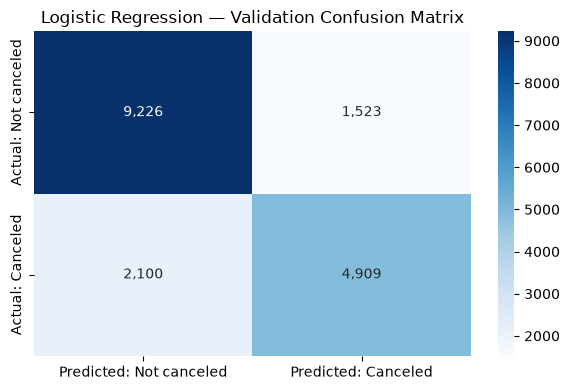

In [9]:
if logistic_model is None:
    print("Complete TODO 3 first.")
else:
    cm = confusion_matrix(y_valid, logistic_predictions)
    tn, fp, fn, tp = cm.ravel()
    confusion_report = pd.DataFrame(
        cm,
        index=["Actual: Not canceled", "Actual: Canceled"],
        columns=["Predicted: Not canceled", "Predicted: Canceled"],
    )
    display(confusion_report)

    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_report, annot=True, fmt=",", cmap="Blues")
    plt.title("Logistic Regression — Validation Confusion Matrix")
    plt.tight_layout()
    plt.show()


### TODO 5 — Connect errors to hotel operations

In this project:

- A **false positive** is a booking predicted to cancel that actually arrives.
- A **false negative** is a booking predicted to arrive that actually cancels.

### Confusion Matrix Results
- **True negatives:** 9,226
- **False positives:** 1,523
- **False negatives:** 2,100
- **True positives:** 4,909

Which error could create more financial harm for StaySure, and why? There is no universal answer—state your business assumption.

## STAYSURE BUSINESS INTERPRETATION based on CONFUSION MATRIX
I assume false negatives create greater financial harm for StaySure. A false negative occurs when the model predicts that a guest will arrive, but the reservation is later canceled. The hotel may hold the room, schedule staff, and plan inventory around that booking, only to lose the expected revenue and potentially leave the room vacant. False positives also carry risk because unnecessary intervention or overbooking could inconvenience guests who actually arrive. However, under the assumption that unused room capacity and lost revenue are the primary concerns, reducing false negatives should receive greater priority.


## 9. Explore probability thresholds


### TODO 6 — Compare several decision thresholds


In [11]:
if logistic_model is None:
    print("Complete TODO 3 first.")
else:
    # TODO 6: Add 0.30, 0.40, 0.50, 0.60, and 0.70.
    THRESHOLDS = [0.30, 0.40, 0.50, 0.60, 0.70]

    if THRESHOLDS is None:
        print("TODO 6: Enter the five thresholds.")
    else:
        threshold_rows = []
        for threshold in THRESHOLDS:
            threshold_predictions = (logistic_probabilities >= threshold).astype(int)
            threshold_rows.append({
                "threshold": threshold,
                "precision": precision_score(y_valid, threshold_predictions, zero_division=0),
                "recall": recall_score(y_valid, threshold_predictions, zero_division=0),
                "f1": f1_score(y_valid, threshold_predictions, zero_division=0),
                "predicted_cancellation_rate": threshold_predictions.mean(),
            })
        threshold_analysis = pd.DataFrame(threshold_rows)
        display(threshold_analysis)


,threshold,precision,recall,f1,predicted_cancellation_rate
0,0.3000,0.6313,0.8724,0.7325,0.5455
1,0.4000,0.6990,0.7920,0.7426,0.4472
2,0.5000,0.7632,0.7004,0.7305,0.3622
3,0.6000,0.8306,0.5800,0.6830,0.2756
4,0.7000,0.8840,0.4861,0.6273,0.2170


**TODO 6 interpretation:** What happens to precision and recall as the threshold increases? Which threshold would you investigate if missing cancellations is especially costly?

## METRICS EVALUATION
As the decision threshold increases, precision increases while recall decreases. The model becomes more selective about labeling reservations as cancellations, producing fewer false positives but missing more actual cancellations. If missing cancellations is especially costly, I would investigate the 0.30 threshold because it provides the highest recall, approximately 87%, although the hotel would need to accept more false-positive alerts. The 0.40 threshold may offer a more balanced operational tradeoff because it provides approximately 79% recall and the highest F1 score among the tested thresholds.

## 10. Save the reproducible outputs


### TODO 7 — Save the selected baseline and reports


In [12]:
if any(name not in globals() for name in ["baseline_metrics", "confusion_report", "threshold_analysis"]):
    print("Complete TODOs 1–6 first.")
else:
    # TODO 7: Replace None with the fitted logistic-regression model.
    MODEL_TO_SAVE = logistic_model
    if MODEL_TO_SAVE is None:
        print("TODO 7: Choose the fitted baseline model to save.")
    else:
        joblib.dump(MODEL_TO_SAVE, MODELS_DIR / "logistic_regression_baseline.joblib")
        baseline_metrics.to_csv(REPORTS_DIR / "milestone_04_baseline_metrics.csv", index=False)
        confusion_report.rename_axis("actual_class").reset_index().to_csv(
            REPORTS_DIR / "milestone_04_confusion_matrix.csv", index=False
        )
        threshold_analysis.to_csv(
            REPORTS_DIR / "milestone_04_threshold_analysis.csv", index=False
        )
        print("Baseline model and three Milestone 4 reports saved.")


Baseline model and three Milestone 4 reports saved.


In [13]:
model_path = MODELS_DIR / "logistic_regression_baseline.joblib"
report_paths = [
    REPORTS_DIR / "milestone_04_baseline_metrics.csv",
    REPORTS_DIR / "milestone_04_confusion_matrix.csv",
    REPORTS_DIR / "milestone_04_threshold_analysis.csv",
]
if model_path.exists() and all(path.exists() for path in report_paths):
    assert logistic_metrics["roc_auc"] > dummy_metrics["roc_auc"]
    assert logistic_metrics["f1"] > dummy_metrics["f1"]
    assert len(threshold_analysis) == 5
    print("Milestone 4 validation checks passed.")
else:
    print("Complete TODO 7 and save all outputs first.")


Milestone 4 validation checks passed.


## Expected result range

Small software-version differences are acceptable. With the recommended settings, validation results should be approximately:

| Model | Accuracy | Precision | Recall | F1 | ROC AUC |
|---|---:|---:|---:|---:|---:|
| Dummy (most frequent) | 0.605 | 0.000 | 0.000 | 0.000 | 0.500 |
| Logistic regression | 0.796 | 0.763 | 0.701 | 0.731 | 0.875 |

If your values differ substantially, stop and check the split dates, feature manifest, and saved preprocessing pipeline.


## Interview-ready summary

Complete this after the notebook runs:

> I established a no-skill majority-class benchmark and compared it with logistic regression using a chronological validation set. I evaluated accuracy, precision, recall, F1, ROC AUC, and the confusion matrix. Logistic regression materially improved cancellation detection and probability ranking. I kept the test set sealed to avoid using it for model selection and examined probability thresholds to connect technical performance with hotel operating costs.


## Questions you should be ready to answer

1. Why use a dummy classifier?
2. Why is accuracy insufficient for this problem?
3. How do precision and recall differ?
4. What does ROC AUC measure?
5. What do false positives and false negatives mean operationally?
6. Why was the test set not used to choose the baseline?
7. How does changing the classification threshold affect decisions?
8. Why is logistic regression a useful baseline?


## Interview-ready answers
1. Why use a dummy classifier?
It provides a no-skill benchmark. A useful trained model must perform better than simply predicting the majority class.

2. Why is accuracy insufficient?
The dummy model achieved about 60% accuracy while detecting zero cancellations. Precision, recall, F1, and ROC AUC reveal performance on the cancellation class.

3. How do precision and recall differ?
Precision measures how many predicted cancellations were correct. Recall measures how many actual cancellations the model detected.

4. What does ROC AUC measure?
It measures how well the model ranks cancellations above non-cancellations across all possible classification thresholds. 0.5 is random ranking; 1.0 is perfect.

5. What do false positives and false negatives mean?
A false positive is predicted to cancel but actually arrives. A false negative is predicted to arrive but actually cancels.

6. Why was the test set not used?
The validation set is used for model comparison and threshold decisions. The test set remains untouched so it can provide an unbiased final performance estimate later.

7. How does changing the threshold affect decisions?
Lower thresholds usually increase recall but create more false positives. Higher thresholds increase precision but miss more actual cancellations.

8. Why is logistic regression useful?
It is fast, interpretable, produces probabilities, and establishes a strong baseline before testing more complex models.


## Milestone 4 completion checklist

- [x] Loaded the cleaned dataset and Milestone 3 artifacts
- [x] Recreated the chronological split
- [x] Kept the test set sealed
- [x] Evaluated a no-skill dummy classifier
- [x] Trained logistic regression
- [x] Compared multiple classification metrics
- [x] Interpreted the confusion matrix
- [x] Analyzed probability thresholds
- [x] Saved the model and three reports
- [x] Can explain the results in business language
